# Estimador Máximo Verosímil


Ejemplo 1. Lanzamos una moneda **100** veces, sabiendo que se obtienen **55** soles. Encontrar el EMV para la probabilidad $p$ de obtener un sol en un sólo lanzamiento.

Sea
$$ X: \text{el número de soles que obtienen al lanzar una moneda} $$
tenemos que $X\sim \text{Bin}(100,p)$, entonces
$$f_{X}(x;p) = \binom{100}{55}p^{55}(1-p)^{100-55}$$

In [ ]:
from scipy.stats import binom
import numpy as np

# Vamos a utilizar la libreria SymPy para matemáticas símbolica
import sympy

from sympy.abc import x # importa la variable simbólica x

https://www.sympy.org/en/features.html

In [ ]:
# Vamos a definir a p como una variable simbólica positiva (de manera manual)
p = sympy.symbols('p', positiva=True)
# Definomps la función de verosimilitud
# omitimos la constante binom{100}{55}
f = p**55 * (1-p)**(100-55)

# Ahora derivamos f con respecto a p
df = sympy.diff(f,p)

# Para encontrar el estimador, igualamos la derivada a cero y despejar p
phat = sympy.solve(df,p)[1] #df=0 para encontra p y [1] para la segunda solución ya que [0] es cero

print("El estimador de máxima verosimilitud para p es", phat)

El estimador de máxima verosimilitud para p es 11/20


Entonces el valor coincide con la proporción de soles.

### Ejemplo 2.

In [ ]:
# Simualaremos una muestra de tamaño 100
# n=1 : un ensayo de Bernoullo
# p: proba de éxito
# size: genera 100 observaciones
r = binom.rvs(n=1,p=0.7,size=100) # Genera v.a. Binomiales
r

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0])

In [ ]:
# Vamos a calcular EMV

# Definimos la función de verosimilitud para una sola observación
f = p**x * (1-p)**(1-x) # x actua como variable simbólica
# Calculamos el producto de todos los elementos
# subs : para sustituir la variable simbolica por valor
J = np.prod([f.subs(x,i) for i in r])

# calculamos el log de J
# sympy.log(J) # log(J)
logJ = sympy.expand_log(sympy.log(J))

phat = sympy.solve(sympy.diff(logJ,p),p)[0]
print("El estimador de máxima verosimilitud para p es", phat)

El estimador de máxima verosimilitud para p es 63/100


In [ ]:
# Podemos revisar las soluciones con:
sol = sympy.solve(sympy.diff(logJ,p),p)
sol

[19/25]

In [ ]:
# Datos observados
datos = np.array([525, 719, 2880, 150, 30, 251, 45, 858, 15, 47, 90, 56, 68, 6, 189, 180, 60, 60, 294, 747])
# Tamaño de la muestra
n = len(datos)

# El estimador es:
media_muestral = np.mean(datos)
print("La media muestral es:", media_muestral)

La media muestral es: 363.5


Se tiene que $\theta=\frac{1}{\mathbb{E}[X]}$, entonces

$$ \hat{\theta} = \frac{1}{\bar{X}} \approx 0.00275$$
por minuto.

Por lo tanto, estimamos que el **tiempo promedio de retardo** entre el inicio de sintomas cardiovasculares y la llegada a la unidad de emergencia es de aproximadamente 363.5 minutos.

**Ejercicio (Pyton)**. Suponga que la vida util de los focos de cierta marca, se modela mediante una distribución expoencial de parametro $\theta$ (desconocido). Probamos 5 focos y encontramos que tienen una vida útil de $2,3,1,3$ y $5$ años, respectivamente. ¿Cuál es el MLE para $\theta$?

Sabemos que

$$ f(x_i;\theta) = \theta \exp(-\theta x_{i}) , x\ge 0, \theta>0 $$

$$ L(x,\theta) = \prod_{i=1}^{n} f(x_i;\theta) = \prod_{i=1}^{n} \theta \exp(-\theta x_{i}) = \theta^{n}e^{-\theta \sum x_i}$$

$$ \ln L(x,\theta) = n\ln(\theta)-\theta\sum_{i}x_i$$

$$\frac{d \ln L(x,\theta)}{d\theta} = \frac{n}{\theta}-\sum_{i}x_i = 0$$

$$ \hat{\theta} = \frac{n}{\sum_{i}x_i} = 1 / \bar{X} $$


In [ ]:
# Datos:
datos = np.array([2,3,1,3,5])
n=len(datos)

suma = np.sum(datos)
media = np.mean(datos)
media

theta = n / suma #(1/media)

print("La media es", media)
print("El estimador de máxima verosimilitud para θ es", theta)


La media es 2.8
El estimador de máxima verosimilitud para θ es 0.35714285714285715


La tasa estimada de falla es de $0.3571$ fallas por año y se tiene que la vida media estimada de los focos es de 2.8 años

**Ejercicio.** Calcular el estimador con Sympy.

# Intervalos de confianza

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

## 1. Intervalo de confianza para la media de una población normal:

Sea $X_1,\dots,X_n$ una m.a $X_i\sim\mathcal{N}(\mu,\sigma^2)$, entonces
 - $\bar{X} \sim \mathcal{N}(\mu,\sigma^2/n)$
 - $Z = \frac{\bar{X}-\mu}{\sigma/n}\sim \mathcal{N}(0,1)$

### - $\sigma$ conocida.

Se tiene que el intervalo del $(1-\alpha)\times 100 \%$ de confianza para $\mu$ es:

$$\bar{X}\pm z_{\alpha/2}\frac{\sigma}{\sqrt{n}}$$

**Ejemplo 1** Para tratar de estimar la media de consumo por cliente en un restaurante, se reunieron datos de una muestra de tamaño $49$ clientes durante tres semanas.

**a)** Supongamos que la desviación estándar de la población es de $\$ 2.5$. ¿Cuál es el error estándadar de la media?

**b)** COn un nivel de confianza del $95\%$, ¿cuál es el margen de error?

**c)** Si ma media de la muestra es de $\$22.60$, cual es el intervalo de confianza del $95\%$ para la media de la población.  

In [ ]:
n=49 # clientes
sigma = 2.5 # d.e.
media_muestral = 22.60
confianza = 0.95

# a) SE
error_est =sigma / np.sqrt(n)
print('El error estándar es:', error_est )

# b) 1-confianza = 0.95 -> 0.025 en cada cola -> (1-confianza)/2
z = st.norm.ppf(1-(1-confianza) / 2) # Percent Point Function
margen_error = z*error_est
print('El margen de error es:', margen_error)

# c) Intervalo de confianza
limite_inf = media_muestral-margen_error
limite_sup = media_muestral+margen_error

print(f'Intercalo del {confianza*100}%: ({limite_inf:.2f},{limite_sup:.2f})')



El error estándar es: 0.35714285714285715
El margen de error es: 0.6999871373357336
Intercalo del 95.0%: (21.90,23.30)


Tenemos un $95\%$ de confianza de que el verdadero consumo poblacional en el restaurante se encuentra entre $\$21.90$ y $\$23.30$

**Ejemplo 2** Supongamos que se toma una muestra aleatoria de 100 personas para estimar la media del peso de una población, y se obtiene que la media muestral es de 70 kg con una desviación estándar que es conocida de 10 kg. Para un nivel de confianza del $95\%$, calcular el intervalo de confianza.

In [ ]:
# datos
n=100
sigma = 10
media_muestral = 70
confianza = 0.95
error_est = sigma/np.sqrt(n)

# Utilizaremos la función
# scypy.stats.norm.interval(confidence,loc,scale)
# confidence = confianza
# loc = media_muestral
# scale = error_est

intervalo = st.norm.interval(confianza, media_muestral, error_est)
print(f'Intervalo de confianza del {confianza*100}%: ({intervalo[0]:.2f},{intervalo[1]:.2f})')


Intervalo de confianza del 95.0%: (68.04,71.96)


Por lo tanto, con un $95\%$ de confianza, estimamos que el peso medio verdadero de la población se encuentra entre $69.04$ kg y $71.96$.

> Se podría practicar modificando el nivel de confianza al $90%$ o $99\%$ para ver como cambia el intervalo.

### - $\sigma$ desconocida

Se tiene que el intervalo del $(1-\alpha)\times 100 \%$ de confianza para $\mu$ es:

$$\bar{X}\pm t_{\alpha/2}\frac{\sigma}{\sqrt{n}}$$

** Ejemplo 3** Supongamos que tenemos los siguientes datos de una muestra aleatoria de 10 observaciones:
$$ 45,55,67,45,68,79,98,87,84,82 $$
Calcular un intervalo de confianza para la media.

In [ ]:
# Datos
datos = [45,55,67,45,68,79,98,87,84,82] # n<=30
n = len(datos)
confianza = 0.95
gl = n-1

media_muestral = np.mean(datos)
error_est = st.sem(datos) #error standar muestral

# Utilizaremos la función
# scypy.stats.t.interval(confidence, df, loc,scale)
# confidence = confianza
# df = degree freedom (gl)
# loc = media_muestral
# scale = error_est
intervalo = st.t.interval(confianza, gl,media_muestral, error_est)

print(media_muestral)
print(f'Intervalo de confianza del {confianza*100}%: ({intervalo[0]:.2f},{intervalo[1]:.2f})')


71.0
Intervalo de confianza del 95.0%: (58.00,84.00)


**Ejemplo 4**
Los articulos de cerámica utilizados sobre velas electricas se rompen con diferenres presiones.
Supongamos que los datos provienen de una distribución normal. La resistencia a la ruptura fue medida en una muestra de 100 artículos y el promedio fue de 1750 con una desviación estandar de 315.8.

**a)** Estimar con un nivel de confianza del $90\%$ a la media poblacional de la presión de la ruptura.

**b)** Estimar con un nivel de confianza del $90\%$ a la varianza poblacional.
        
$$ \left(
 \frac{(n - 1) s^2}{\chi^2_{1 - \alpha/2}} ,
 \frac{(n - 1) s^2}{\chi^2_{\alpha/2}}
\right) $$

In [ ]:
# Datos
n = 100
confianza = 0.90
media_muestral = 1750
desv_est = 315.8
error_est = desv_est / np.sqrt(n)

# a) Utilzamos z ya que n>=30

intervalo = st.norm.interval(confianza, media_muestral, error_est)
print(f'Intervalo de confianza del {confianza*100}%: ({intervalo[0]:.2f},{intervalo[1]:.2f})')

# b) IC para la varianza Chi-cuadrara
gl = n-1
alpha = 1-confianza
s2 = desv_est**2 # varianza muestral

# Forma 1. calculando los cuatiles de la chi-cuadrada
chi_inf = st.chi2.ppf(alpha/2, gl)  #χ²_{0.05, 99}= 77.04
chi_sup = st.chi2.ppf(1-alpha / 2, gl) #  χ²_{0.95, 99} = 123.22
chi_inf, chi_sup

int_var = ((gl*s2) / chi_sup, (gl*s2) / chi_inf)
print(f'Intervalo de confianza para la varianza del {confianza*100}%: ({int_var[0]:.2f},{int_var[1]:.2f})')

# Forma 2.
chi2_inf, chi2_sup = st.chi2.interval(confianza, gl)
int_var2 = ((gl*s2) / chi2_sup, (gl*s2) / chi2_inf)
print(f'Intervalo de confianza para la varianza del {confianza*100}%: ({int_var2[0]:.2f},{int_var2[1]:.2f})')

Intervalo de confianza del 90.0%: (1698.06,1801.94)
Intervalo de confianza para la varianza del 90.0%: (80123.49,128146.72)
Intervalo de confianza para la varianza del 90.0%: (80123.49,128146.72)


# Distribuciones muestrales

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, t, f, norm

## Distribución Chi-Cuadrada

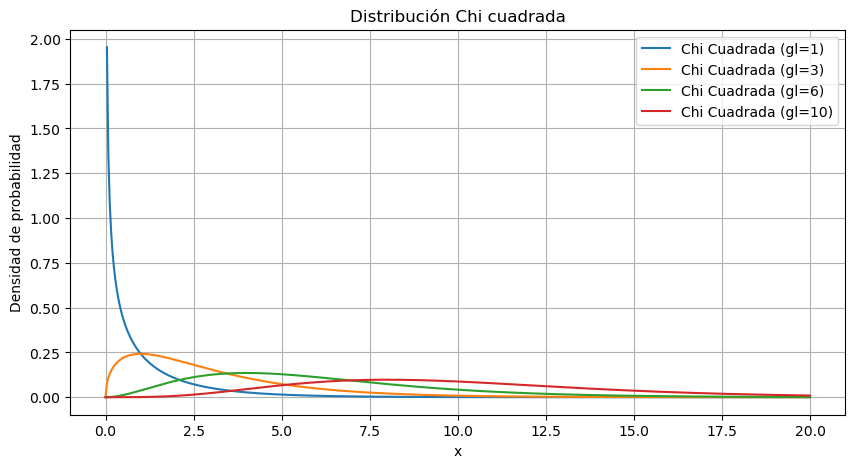

In [ ]:
x_chi = np.linspace(0,20,500)

plt.figure(figsize=(10,5))

# Damos los grados de libertdad
gl_chi = [1,3,6,10]

for gl in gl_chi:
    plt.plot(x_chi, chi2.pdf(x_chi,gl), label=f'Chi Cuadrada (gl={gl})')
plt.title('Distribución Chi cuadrada')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid()
plt.show()

## t de Student

x = np.linspace(-5,5,500) # eje de la x

# Gados de libertad
gl_t = [1,3,10,30]

plt.figure(figsize=(10,6))
for gl in gl_t:
    plt.plot(x,t.pdf(x,gl), label=f't (gl={gl})')

plt.plot(x,norm.pdf(x), 'k--', label='Normal estándar')

plt.title('Distribución t de Student')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid()
plt.show()      

## F de Fisher

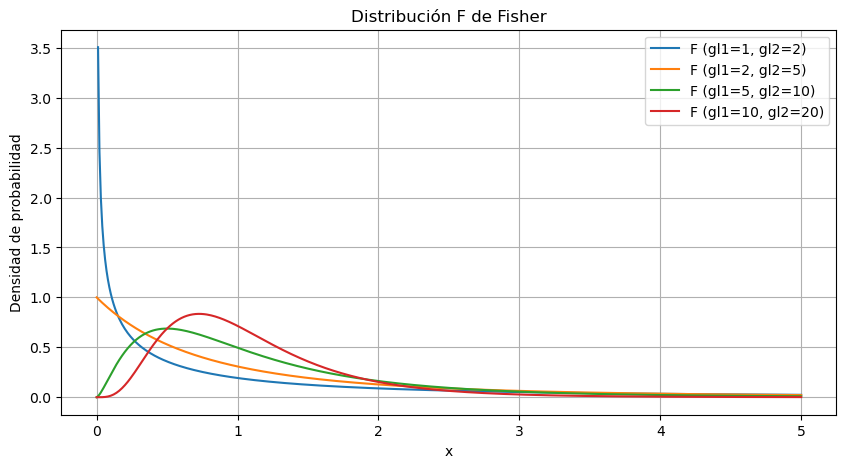

In [ ]:
x = np.linspace(0,5,500)

gl_f = [(1,2),(2,5),(5,10),(10,20)] # (gl1,gl2)

plt.figure(figsize=(10,5))

for d1,d2 in gl_f:
    plt.plot(x, f.pdf(x,d1,d2), label=f'F (gl1={d1}, gl2={d2})')

plt.title('Distribución F de Fisher')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid()
plt.show()